# LAB 6a: Clustering Techniques (K-Means, Mean Shift, DBSCAN)
**Mục tiêu:**
- Hiểu sâu bản chất toán học của K-Means thông qua việc tự cài đặt (Manual) bằng Numpy.
- Phân biệt sự hiệu quả giữa việc khởi tạo tâm cụm ngẫu nhiên (`random`) và thuật toán thông minh `K-Means++`.
- Sử dụng phương pháp Elbow và Silhouette Score để tìm ra số lượng cụm (K) tối ưu.
- Áp dụng trên tập dữ liệu thực tế (Customer Segmentation).
- Nhận diện điểm yếu của K-Means trên dữ liệu phi tuyến (non-linear) và khắc phục bằng DBSCAN.

In [1]:
# Import các thư viện nền tảng cho toàn bộ Lab
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_blobs, make_moons
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# Cài đặt giao diện đồ thị
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

## PHẦN A: K-MEANS THỦ CÔNG
### Bước 1 & 2: Cài đặt thuật toán K-Means từ đầu
Quá trình K-Means bao gồm 3 bước lặp đi lặp lại:
1. **Khởi tạo (Initialization):** Chọn K điểm làm tâm cụm (Centroids). Ta sẽ cài đặt cả 2 cách: Random và K-Means++ (chọn tâm cụm sao cho chúng cách xa nhau nhất có thể).
2. **Gán nhãn (Assign):** Tính khoảng cách từ mọi điểm dữ liệu đến các tâm, điểm nào gần tâm nào nhất thì thuộc về cụm đó.
3. **Cập nhật (Update):** Tính lại trung bình tọa độ của các điểm trong mỗi cụm để làm tâm cụm mới. Dừng lại khi tâm cụm không thay đổi.

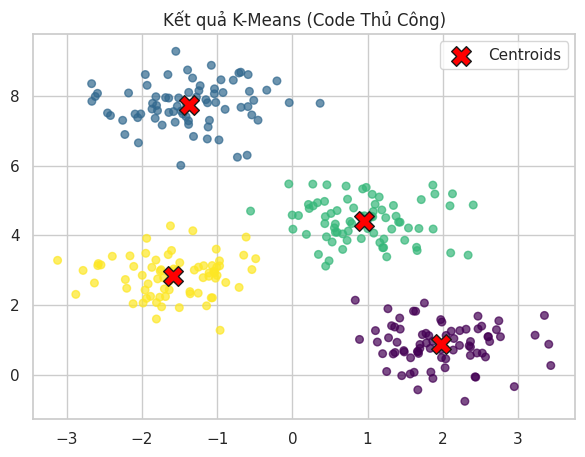

In [2]:
class ManualKMeans:
    def __init__(self, k=3, max_iters=100, init_method='random'):
        self.k = k
        self.max_iters = max_iters
        self.init_method = init_method
        self.centroids = None
        self.labels = None

    def fit(self, X):
        # 1. Khởi tạo tâm cụm (Initialization)
        if self.init_method == 'random':
            # Chọn ngẫu nhiên K điểm trong tập dữ liệu
            random_idx = np.random.choice(len(X), self.k, replace=False)
            self.centroids = X[random_idx]
        elif self.init_method == 'k-means++':
            # Điểm đầu tiên chọn ngẫu nhiên
            self.centroids = [X[np.random.randint(len(X))]]
            # Các điểm tiếp theo chọn dựa trên khoảng cách xa nhất
            for _ in range(1, self.k):
                # Tính khoảng cách bình phương từ mỗi điểm tới tâm gần nhất
                dists = np.min([np.linalg.norm(X - c, axis=1)**2 for c in self.centroids], axis=0)
                probs = dists / dists.sum()
                cumprobs = np.cumsum(probs)
                r = np.random.rand()
                next_centroid = X[np.searchsorted(cumprobs, r)]
                self.centroids.append(next_centroid)
            self.centroids = np.array(self.centroids)

        # Vòng lặp tối ưu
        for _ in range(self.max_iters):
            # 2. Gán nhãn (Assign points to nearest centroid)
            distances = np.array([np.linalg.norm(X - c, axis=1) for c in self.centroids])
            self.labels = np.argmin(distances, axis=0)

            # 3. Cập nhật tâm cụm (Update centroids)
            new_centroids = np.array([
                X[self.labels == i].mean(axis=0) if sum(self.labels == i) > 0 else self.centroids[i]
                for i in range(self.k)
            ])

            # Nếu tâm cụm không đổi -> Hội tụ
            if np.allclose(self.centroids, new_centroids):
                break
            self.centroids = new_centroids

        return self

# --- THỬ NGHIỆM TRÊN DỮ LIỆU GIẢ LẬP ---
# Tạo dữ liệu giả lập (Make Blobs)
X_dummy, y_dummy = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)

# Chạy mô hình K-Means++ thủ công
manual_kmeans = ManualKMeans(k=4, init_method='k-means++')
manual_kmeans.fit(X_dummy)

# Trực quan hóa kết quả
plt.figure(figsize=(7, 5))
plt.scatter(X_dummy[:, 0], X_dummy[:, 1], c=manual_kmeans.labels, cmap='viridis', s=30, alpha=0.7)
plt.scatter(manual_kmeans.centroids[:, 0], manual_kmeans.centroids[:, 1], c='red', s=200, marker='X', edgecolor='k', label='Centroids')
plt.title("Kết quả K-Means (Code Thủ Công)")
plt.legend()
plt.show()

### Bước 3 & 4: Elbow Method và Silhouette Score
Để tìm số lượng cụm $K$ tối ưu một cách khoa học (thay vì đoán mò), ta chạy K-Means với nhiều giá trị $K$ khác nhau.
- **Elbow Method:** Tìm điểm "cùi chỏ" trên đồ thị hàm mất mát (Inertia/WCSS - Tổng bình phương khoảng cách trong nội bộ cụm).
- **Silhouette Score:** Đo lường mức độ tương đồng của một đối tượng với chính cụm của nó so với các cụm khác (Chỉ số từ -1 đến 1, càng gần 1 càng tốt).
*(Ở bước này ta dùng thư viện `sklearn.cluster.KMeans` cho tốc độ xử lý nhanh gọn).*

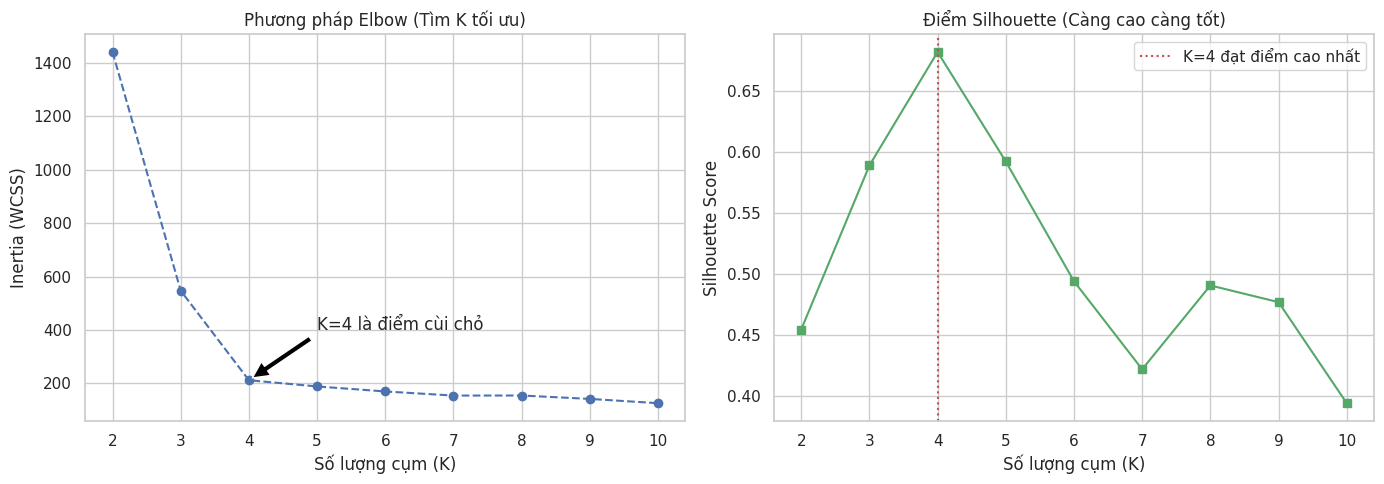

In [3]:
inertia_values = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(X_dummy)
    inertia_values.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_dummy, kmeans.labels_))

# Trực quan hóa song song 2 phương pháp
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Elbow Plot
axes[0].plot(K_range, inertia_values, marker='o', linestyle='--', color='b')
axes[0].set_title('Phương pháp Elbow (Tìm K tối ưu)')
axes[0].set_xlabel('Số lượng cụm (K)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].annotate('K=4 là điểm cùi chỏ', xy=(4, inertia_values[2]), xytext=(5, 400),
             arrowprops=dict(facecolor='black', shrink=0.05))

# 2. Silhouette Plot
axes[1].plot(K_range, silhouette_scores, marker='s', linestyle='-', color='g')
axes[1].set_title('Điểm Silhouette (Càng cao càng tốt)')
axes[1].set_xlabel('Số lượng cụm (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].axvline(x=4, color='r', linestyle=':', label='K=4 đạt điểm cao nhất')
axes[1].legend()

plt.tight_layout()
plt.show()

## PHẦN B: CUSTOMER SEGMENTATION (Phân khúc Khách hàng)
### Bước 5 & 6: Load dữ liệu Mall Customers, EDA và Áp dụng K-Means
Tải trực tiếp tập dữ liệu Mall Customers. Dữ liệu gồm các thông tin: Tuổi, Thu nhập hàng năm (Annual Income) và Điểm chi tiêu (Spending Score). Mục tiêu là phân nhóm khách hàng để lên chiến lược Marketing.

--- 5 DÒNG DỮ LIỆU ĐẦU TIÊN ---


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


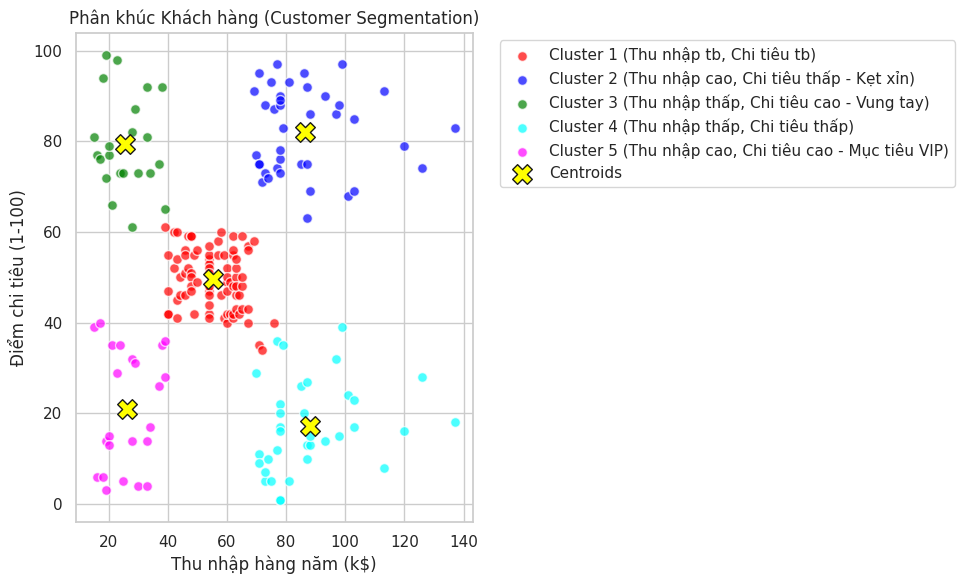

In [4]:
# 1. Tải dữ liệu trực tiếp từ kho lưu trữ github tiêu chuẩn
url_mall = 'https://raw.githubusercontent.com/tirthajyoti/Machine-Learning-with-Python/master/Datasets/Mall_Customers.csv'
df_mall = pd.read_csv(url_mall)

print("--- 5 DÒNG DỮ LIỆU ĐẦU TIÊN ---")
display(df_mall.head())

# Lấy 2 đặc trưng quan trọng nhất để dễ dàng trực quan hóa 2D: Thu nhập và Điểm chi tiêu
X_mall = df_mall.iloc[:, [3, 4]].values

# 2. Chạy K-Means với K=5 (Dựa theo quy chuẩn thường thấy của tập dữ liệu này)
kmeans_mall = KMeans(n_clusters=5, init='k-means++', random_state=42)
y_kmeans_mall = kmeans_mall.fit_predict(X_mall)

# 3. Trực quan hóa các phân khúc khách hàng
plt.figure(figsize=(10, 6))

colors = ['red', 'blue', 'green', 'cyan', 'magenta']
labels = [
    'Cluster 1 (Thu nhập tb, Chi tiêu tb)',
    'Cluster 2 (Thu nhập cao, Chi tiêu thấp - Kẹt xỉn)',
    'Cluster 3 (Thu nhập thấp, Chi tiêu cao - Vung tay)',
    'Cluster 4 (Thu nhập thấp, Chi tiêu thấp)',
    'Cluster 5 (Thu nhập cao, Chi tiêu cao - Mục tiêu VIP)'
]

for i in range(5):
    plt.scatter(X_mall[y_kmeans_mall == i, 0], X_mall[y_kmeans_mall == i, 1],
                s=50, c=colors[i], label=labels[i], alpha=0.7, edgecolors='w')

# Vẽ tâm cụm
plt.scatter(kmeans_mall.cluster_centers_[:, 0], kmeans_mall.cluster_centers_[:, 1],
            s=200, c='yellow', marker='X', edgecolor='k', label='Centroids')

plt.title('Phân khúc Khách hàng (Customer Segmentation)')
plt.xlabel('Thu nhập hàng năm (k$)')
plt.ylabel('Điểm chi tiêu (1-100)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## PHẦN C: SO SÁNH VỚI DBSCAN (Density-Based Spatial Clustering)
### Bước 7 & 8: Điểm yếu của K-Means và Sức mạnh của DBSCAN
K-Means phân cụm dựa trên khoảng cách tuyến tính đến tâm hình học, do đó nó mặc định các cụm phải có hình cầu (hình tròn). Khi gặp dữ liệu có hình dạng bất quy tắc (như 2 hình bán nguyệt lồng vào nhau), K-Means sẽ thất bại hoàn toàn.

Lúc này, **DBSCAN** - thuật toán phân cụm dựa trên mật độ dữ liệu - sẽ tỏa sáng.

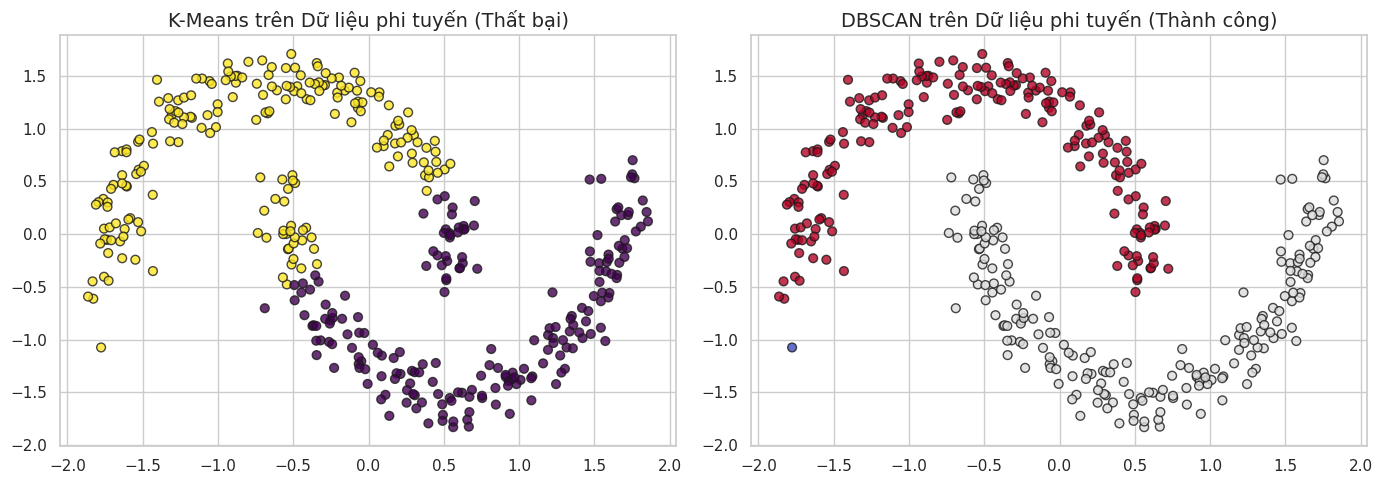

In [5]:
# Tạo dữ liệu phi tuyến (Hai nửa mặt trăng)
X_moons, _ = make_moons(n_samples=400, noise=0.08, random_state=42)

# Chuẩn hóa dữ liệu (Cực kỳ quan trọng đối với DBSCAN)
X_moons_scaled = StandardScaler().fit_transform(X_moons)

# 1. Chạy K-Means
kmeans_moons = KMeans(n_clusters=2, random_state=42)
y_kmeans_moons = kmeans_moons.fit_predict(X_moons_scaled)

# 2. Chạy DBSCAN
# eps: Bán kính tìm kiếm láng giềng
# min_samples: Số lượng điểm tối thiểu để tạo thành vùng lõi (core)
dbscan = DBSCAN(eps=0.25, min_samples=5)
y_dbscan = dbscan.fit_predict(X_moons_scaled)

# 3. Trực quan hóa So sánh song song
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Đồ thị K-Means (Sẽ cắt đôi 2 nửa mặt trăng một cách vô lý)
axes[0].scatter(X_moons_scaled[:, 0], X_moons_scaled[:, 1], c=y_kmeans_moons, cmap='viridis', s=40, edgecolor='k', alpha=0.8)
axes[0].set_title('K-Means trên Dữ liệu phi tuyến (Thất bại)', fontsize=14)

# Đồ thị DBSCAN (Sẽ nhóm đúng dựa trên sự liền kề của mật độ điểm)
# Lưu ý: DBSCAN gán nhãn -1 cho các điểm nhiễu (Outliers)
axes[1].scatter(X_moons_scaled[:, 0], X_moons_scaled[:, 1], c=y_dbscan, cmap='coolwarm', s=40, edgecolor='k', alpha=0.8)
axes[1].set_title('DBSCAN trên Dữ liệu phi tuyến (Thành công)', fontsize=14)

plt.tight_layout()
plt.show()